Agglomerative Clustering:
[0 0 0 1 1 1 2 2 2]


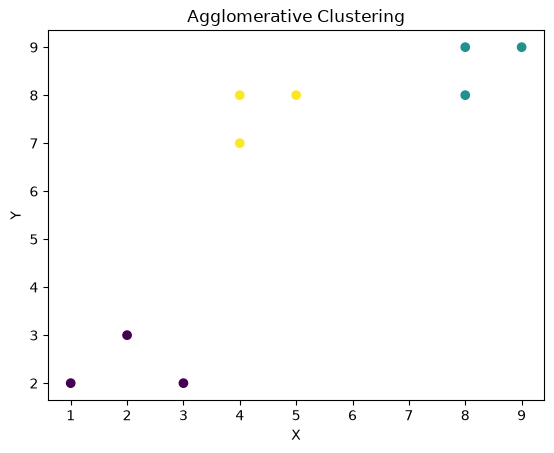


Divisive Clustering:
Cluster 1 :
[[1 2]
 [2 3]
 [3 2]]
Cluster 2 :
[[8 8]
 [9 9]
 [8 9]]
Cluster 3 :
[[4 7]
 [5 8]
 [4 8]]


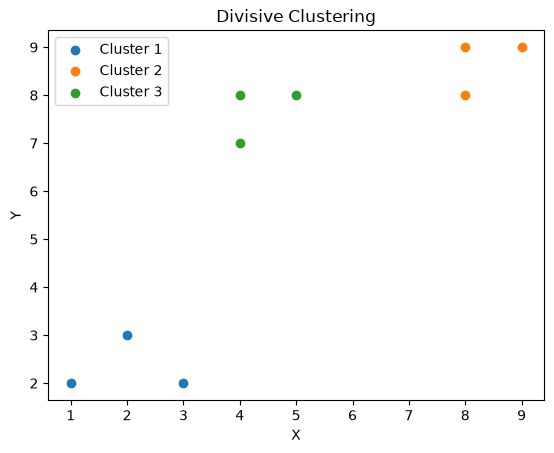

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans

# Sample data
X = np.array([
    [1, 2], [2, 3], [3, 2],
    [8, 8], [9, 9], [8, 9],
    [4, 7], [5, 8], [4, 8]
])

# -------------------------
# Agglomerative Clustering
# -------------------------

agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X)

print("Agglomerative Clustering:")
print(agg_labels)

plt.scatter(X[:, 0], X[:, 1], c=agg_labels)
plt.title("Agglomerative Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


# -------------------------
# Divisive Clustering
# -------------------------

def divisive_clustering(X, n_clusters):

    clusters = [X]

    while len(clusters) < n_clusters:

        # Take the largest cluster
        largest = max(clusters, key=len)
        clusters.remove(largest)

        # Split into 2 clusters
        kmeans = KMeans(
            n_clusters=2,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(largest)

        clusters.append(largest[labels == 0])
        clusters.append(largest[labels == 1])

    return clusters


clusters = divisive_clustering(X, 3)

print("\nDivisive Clustering:")

for i, cluster in enumerate(clusters):
    print("Cluster", i + 1, ":")
    print(cluster)

# Plot
for i, cluster in enumerate(clusters):
    plt.scatter(cluster[:, 0], cluster[:, 1], label="Cluster " + str(i + 1))

plt.title("Divisive Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()